# Utilizations for data extraction

## Prepare things

In [1]:
import os
import cv2
import glob
import numpy as np
import random as rnd
import mediapipe as mp
from datetime import datetime
from matplotlib import pyplot as plt
%pwd

2026-07-10 00:54:09.577707: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/data-extraction'

In [2]:
def FName():
    now = datetime.now()
    date_time_str = now.strftime("%Y-%m-%d_%H%M%S")
    return date_time_str 

def load_kalibrasi(npz_path):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"File {npz_path} tidak ditemukan.")

    with np.load(npz_path) as data:
        print(data.files)
        K_left, D_left      = data['K_left'], data['D_left']
        K_right, D_right    = data['K_right'], data['D_right']
        R, T                = data['R'], data['T'] 
        
    return K_left, D_left, K_right, D_right, R, T

def image_show(image):
    plt.imshow(image)

## Calibrate camera
Kalibrasi dilakukan dengan:
1.  Memastikan gambar yang masuk adalah ukuran 1280x720 @ 1 camera. Stereo -> 2 camera @ 1280x720 -> 2 frame disatukan 2560x720

In [ ]:
def Calibrating_s(filename):    
    print("Calibrating..")
    CHESSBOARD_SIZE = (8, 6)
    SQUARE_SIZE = 0.03
    
    # Array untuk menyimpan titik-titik 3D dunia dan 2D di gambar
    obj_points = []
    img_points_left = []
    img_points_right = []

    # Generate koordinat dunia 3D (koordinat objek catur)
    objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1, 2) * SQUARE_SIZE

    # Ambil daftar gambar untuk kalibrasi
    images_left = sorted(glob.glob(
        r'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/PDTremor/0-2024-01-16_115450/stereoLeft/imageL*.png'
        ))  # Ganti dengan pola nama gambar di direktori
    
    images_right = sorted(glob.glob(
        r'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/PDTremor/0-2024-01-16_115450/stereoRight/imageR*.png'
        ))  # Ganti dengan pola nama gambar di direktori
    
    # # Ambil daftar gambar untuk kalibrasi
    # images_left = sorted(glob.glob(
    #     r'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/2024-old-training-model/0-2024-06-06_190014/stereoLeft/imageL*.png'
    #     ))  # Ganti dengan pola nama gambar di direktori
    
    # images_right = sorted(glob.glob(
    #     r'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/2024-old-training-model/0-2024-06-06_190014/stereoRight/imageR*.png'
    #     ))  # Ganti dengan pola nama gambar di direktori
    
    if len(images_left) != len(images_right):
        raise ValueError(
            f"Jumlah gambar kiri dan kanan tidak sama: "
            f"{len(images_left)} vs {len(images_right)}"
        )

    valid_pairs = 0
    failed_pairs = 0
    for i in range(len(images_left)):
        img_left    = cv2.imread(images_left[i])
        img_right   = cv2.imread(images_right[i])
        img_left    = cv2.resize(img_left,  (1280, 720), interpolation = cv2.INTER_CUBIC)
        img_right   = cv2.resize(img_right, (1280, 720), interpolation = cv2.INTER_CUBIC)
        gray_left   = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
        gray_right  = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

        if i == 0:
            print(f'input size: {img_left.shape} and {img_right.shape}')

        retL, cornersL = cv2.findChessboardCorners(gray_left,  CHESSBOARD_SIZE, None)
        retR, cornersR = cv2.findChessboardCorners(gray_right, CHESSBOARD_SIZE, None)
        if retL and retR:
            valid_pairs+=1
            # Refine corner positions
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
            cornersL = cv2.cornerSubPix(gray_left,  cornersL, (11,11), (-1,-1), criteria)
            cornersR = cv2.cornerSubPix(gray_right, cornersR, (11,11), (-1,-1), criteria)
                
            # Tambahkan titik 3D dan 2D ke array
            obj_points.append(objp)
            img_points_left.append(cornersL)
            img_points_right.append(cornersR)
        else:
            failed_pairs += 1
            print(
                "Failed:",
                os.path.basename(images_left[i]),
                os.path.basename(images_right[i]),
                "left:", retL,
                "right:", retR
            )

    if valid_pairs < 10:
        raise ValueError("Pasangan valid terlalu sedikit untuk stereo calibration.")
    
    image_size = gray_left.shape[::-1]
    print(f"Image size : {image_size}")

    # # Ambil informasi kamera
    retL, K_left, D_left, rvecs_left, tvecs_left    = cv2.calibrateCamera(obj_points, 
                                                                        img_points_left, 
                                                                        image_size, None, None, None, criteria)
    # Ambil informasi kamera
    retR, K_right, D_right, rvecs_right, tvecs_right= cv2.calibrateCamera(obj_points, 
                                                                        img_points_right, 
                                                                        image_size, None, None, None, criteria)
    
    print("\nSingle camera RMS error:")
    print("Left RMS :", retL)
    print("Right RMS:", retR)

    #  --- FILTER DATA LOOP ---
    # We will temporarily calculate individual camera metrics to find bad frames
    clean_objectPoints = []
    clean_imagePointsL = []
    clean_imagePointsR = []

    # Loop through every frame and calculate its specific error contribution
    for i in range(len(obj_points)):
        # Project the 3D points back onto the 2D left camera image plane
        imgpoints2, _ = cv2.projectPoints(obj_points[i], rvecs_left[i], tvecs_left[i], K_left, D_left)
        
        # Force both arrays into a clean, flat 2D shape [-1, 2]
        pts_actual = np.squeeze(img_points_left[i]).astype(np.float32)
        pts_projected = np.squeeze(imgpoints2).astype(np.float32)
        
        # Ensure they have the exact same shape before running cv2.norm
        if pts_actual.shape == pts_projected.shape:
            # Calculate the absolute difference error for this specific frame
            error = cv2.norm(pts_actual, pts_projected, cv2.NORM_L2) / len(pts_projected)
            
            # Only keep the frame if its individual error is acceptable
            if error < 0.1:  # Bumped to 0.8 to make sure we don't drop too many frames at first
                clean_objectPoints.append(obj_points[i])
                clean_imagePointsL.append(img_points_left[i])
                clean_imagePointsR.append(img_points_right[i])
        else:
            print(f"Skipping frame {i} due to critical point count mismatch: {pts_actual.shape} vs {pts_projected.shape}")

    print(f"Jumlah objek yang lolos seleksi: {len(clean_objectPoints)}")

    # # Lakukan kalibrasi kamera stereo
    # flags = 0
    # flags |= cv2.CALIB_USE_INTRINSIC_GUESS

    # The definitive flag combination for the HBV-1790-2 dual module
    # Optimal flag configuration for HBV Rigid Binocular modules
    stereo_flags = (
        cv2.CALIB_FIX_ASPECT_RATIO  |     # Enforces fx/fy ratio from individual calibrations
        cv2.CALIB_SAME_FOCAL_LENGTH |     # Forces fx_left == fx_right and fy_left == fy_right
        cv2.CALIB_ZERO_TANGENT_DIST      # Forces p1, p2 to 0 (reduces noise in cheaper lenses)
        # cv2.CALIB_RATIONAL_MODEL          # Supports the wider angle distortion of the HBV module
    )
    
    criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # ret, mtx_left, dist_left, mtx_right, dist_right
    ret_stereo, K_left, D_left, K_right, D_right, R, T, E, F = cv2.stereoCalibrate(clean_objectPoints, clean_imagePointsL, clean_imagePointsR,
                                                                            K_left, D_left, K_right, D_right,
                                                                            image_size, criteria=criteria_stereo, flags=stereo_flags)
    print("\nStereo RMS error:", ret_stereo)
    print("ret: \n",ret_stereo, "\nKL: \n", K_left, "\nDL: \n", D_left, 
            "\nKR: \n", K_right, "\nDR: \n", D_right, "\nR: \n", R, 
            "\nT: \n", T, "\nE: \n", E, "\nF: \n", F)

    # Simpan parameter kalibrasi untuk digunakan selanjutnya
    np.savez(filename, K_left=K_left, D_left=D_left, K_right=K_right, D_right=D_right, R=R, T=T, E=E, F=F)

    print("Kalibrasi selesai. Parameter disimpan di '%s'" % (filename))
    # return cornersL, cornersR

Calibrating_s(r'Kalibrasi/New-Kalibrasi-07072026.npz')

Calibrating..
input size: (720, 1280, 3) and (720, 1280, 3)
Image size : (1280, 720)

Single camera RMS error:
Left RMS : 1.377954838835303
Right RMS: 1.7712354245285316
Jumlah objek yang lolos seleksi: 32

Stereo RMS error: 0.5660244005030581
ret: 
 0.5660244005030581 
KL: 
 [[1.86315849e+03 0.00000000e+00 7.27081376e+02]
 [0.00000000e+00 1.39862747e+03 3.21774474e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]] 
DL: 
 [[-0.47083303  0.60540928  0.          0.         -2.03460723]] 
KR: 
 [[1.86315849e+03 0.00000000e+00 7.28172433e+02]
 [0.00000000e+00 1.39862747e+03 3.26828567e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]] 
DR: 
 [[-0.45296766  0.57749461  0.          0.         -1.30554552]] 
R: 
 [[ 0.99970628  0.00123965 -0.02420355]
 [-0.00100853  0.9999538   0.00955901]
 [ 0.02421428 -0.0095318   0.99966135]] 
T: 
 [[-0.06159065]
 [ 0.00085411]
 [-0.00365395]] 
E: 
 [[ 1.69965049e-05  3.64563679e-03  8.88746502e-04]
 [-2.16150013e-03 -5.91599229e-04  6.16582334e-02]


## Stereo Match and PointCloud Generator

### Rectify Image

In [ ]:
def rectify_validation(filename):
    image = cv2.imread(filename)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (2560, 720), cv2.INTER_CUBIC)

    alpha = 0.5

    file_kalibrasi_path = './Kalibrasi/New-Kalibrasi-07072026.npz'
    K_left, D_left, K_right, D_right, R, T = load_kalibrasi(file_kalibrasi_path)
    # print(K_right)

    height, width, _= image.shape   

    kiri = image[:, :width // 2]
    kanan = image[:, width //2:]
    kw, kh = kiri.shape[1], kiri.shape[0]

    imgLS = (kiri.shape[1], kiri.shape[0])
    imgRS = (kanan.shape[1], kanan.shape[0])

    # Rectification Parameters
    R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(K_left, D_left, K_right, D_right, imgLS, R, T, alpha=0)x    

    # Undistort dan rectify gambar
    map_left_x, map_left_y   = cv2.initUndistortRectifyMap(K_left, D_left, R1, P1, imgLS, cv2.CV_32FC1)
    map_right_x, map_right_y = cv2.initUndistortRectifyMap(K_right, D_right, R2, P2, imgRS, cv2.CV_32FC1)

    img_left_rectifieds = cv2.remap(kiri, map_left_x, map_left_y, cv2.INTER_LINEAR)
    blur = cv2.GaussianBlur(img_left_rectifieds, (3, 3), 0)
    img_left_rectified = cv2.addWeighted(blur, alpha, img_left_rectifieds, (1-alpha), 0)

    img_right_rectifieds = cv2.remap(kanan, map_right_x, map_right_y, cv2.INTER_LINEAR)
    blur = cv2.GaussianBlur(img_right_rectifieds, (3, 3), 0)
    img_right_rectified = cv2.addWeighted(blur, alpha, img_right_rectifieds, (1-alpha), 0)


    hcombinedA = np.hstack([img_left_rectified, img_right_rectified])
    # vcombiendA = np.vstack((hcombinedA, hcombinedB))

    imgrayL = cv2.cvtColor(img_left_rectified, cv2.COLOR_RGB2GRAY)
    imgrayR = cv2.cvtColor(img_right_rectified, cv2.COLOR_RGB2GRAY)
    hcombinedB = np.hstack([imgrayL, imgrayR])

    # plt.imshow(hcombinedB, cmap='gray')
    return imgrayL, imgrayR, img_left_rectified, img_right_rectified, Q, P1

### Stereo Matching and WLS Filter

amik: {blockSize:0, lmbda:100000, sigma:1.75, filterCap:64, disparity: 10} 
bryan:{blockSize:0, lmbda:100000, sigma:1.75, filterCap:64, disparity: 10}
cucu: {blockSize:0, lmbda:100000, sigma:1.75, filterCap:64, disparity: 10}
dion: {blockSize:0, lmbda:100000, sigma:1.55, filterCap:64, disparity: 10}
ema:  {blockSize:0, lmbda:100000, sigma:1.75, filterCap:64, disparity: 10}
iwap: {blockSize:0, lmbda:100000, sigma:1.75, filterCap:64, disparity: 16}
umam: {blockSize:0, lmbda:100000, sigma:1.25, filterCap:64, disparity: 8}

In [ ]:
def main_stereo_wls(imgL, imgR, resolution=1.0,    # [0, 1.0]
                    numDisparities  = 16,          # has to be dividable by 16
                    blockSize       = 3,           # [0, 25]
                    filterCap       = 63,          # [0, 100]
                    lmbda           = 8000,        # [80000, 100000]
                    sigma           = 1.2,         # [0.8, 2.0]
                    channels        = 1):
    
    windowSize = blockSize      
    
    left_matcher = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities= numDisparities * 16,  # max_disp has to be dividable by 16 f. E. HH 192, 256
        blockSize= blockSize,
        P1= 8 * channels * windowSize **2 , #
        P2= 32 * channels * windowSize **2,
        disp12MaxDiff= 1,
        uniquenessRatio= 15,
        speckleWindowSize= 150,
        speckleRange= 2,
        preFilterCap= filterCap,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)

    # Step 5 - Setup a disparity filter to deal with stereo-matching errors.
    #          It will detect inaccurate disparity values and invalidate them, therefore making the disparity map semi-sparse.
    wls_filter = cv2.ximgproc.createDisparityWLSFilter(matcher_left = left_matcher)
    wls_filter.setLambda(lmbda)
    wls_filter.setSigmaColor(sigma)

    # Step 6 - Perform stereo matching to compute disparity maps for both left and right views.
    displ = left_matcher.compute(imgL, imgR)
    dispr = right_matcher.compute(imgR, imgL)
    displ = np.int16(displ)
    dispr = np.int16(dispr)
    
    # Step 7 - Perform post-filtering
    filtered_raw    = wls_filter.filter(displ, imgL, None, dispr)
    filtered_raw    = np.int16(filtered_raw)
    disparity_float = filtered_raw.astype(np.float32) / 16.0

    disparity_vis   = cv2.normalize(disparity_float, None, beta=0, alpha=255, norm_type=cv2.NORM_MINMAX)
    disparity_vis   = np.uint8(disparity_vis)

    print(disparity_float.shape)
    print(disparity_vis.shape)

    print("displ dtype:", displ.dtype)
    print("displ min/max raw:", displ.min(), displ.max())

    print("filtered_raw dtype:", filtered_raw.dtype)
    print("filtered_raw min/max:", filtered_raw.min(), filtered_raw.max())

    print("disparity_float min/max:", disparity_float.min(), disparity_float.max())
    
    return displ, dispr, disparity_float, disparity_vis

### Project to PointCloud Functions

In [ ]:
def disparity_to_pointcloud_debug(
    disparity_float,
    rect_left_color,
    Q,
    min_disparity=0.1,
    max_depth=None,
    use_abs_z=True
):
    disparity_float = disparity_float.astype(np.float32)

    print("=== Disparity Info ===")
    print("min:", np.nanmin(disparity_float))
    print("max:", np.nanmax(disparity_float))
    print("count > min_disparity:", np.sum(disparity_float > min_disparity))

    points_3d = cv2.reprojectImageTo3D(
        disparity_float,
        Q
    )

    mask = disparity_float > min_disparity
    mask = mask & np.isfinite(disparity_float)

    points = points_3d[mask]

    if len(points) == 0:
        print("Tidak ada point setelah filter disparity.")
        return np.empty((0, 3)), np.empty((0, 3), dtype=np.uint8)

    if len(rect_left_color.shape) == 2:
        colors_img = cv2.cvtColor(
            rect_left_color,
            cv2.COLOR_GRAY2RGB
        )
    else:
        colors_img = cv2.cvtColor(
            rect_left_color,
            cv2.COLOR_BGR2RGB
        )

    colors = colors_img[mask]

    valid = np.isfinite(points).all(axis=1)

    points = points[valid]
    colors = colors[valid]

    if len(points) == 0:
        print("Tidak ada point setelah filter finite.")
        return np.empty((0, 3)), np.empty((0, 3), dtype=np.uint8)

    z = points[:, 2]

    print("=== Z Before Depth Filter ===")
    print("Z min:", np.nanmin(z))
    print("Z max:", np.nanmax(z))
    print("Z mean:", np.nanmean(z))
    print("count Z > 0:", np.sum(z > 0))
    print("count Z < 0:", np.sum(z < 0))

    if use_abs_z:
        depth = np.abs(z)
    else:
        depth = z

    if max_depth is not None:
        valid_depth = depth < max_depth
        points = points[valid_depth]
        colors = colors[valid_depth]

    print("Final points:", len(points))

    return points, colors

def save_pointcloud_ply(filename, points, colors=None):
    """
    Menyimpan pointcloud ke file PLY.
    Bisa dibuka dengan MeshLab, CloudCompare, Open3D, atau Blender.
    """

    points = points.reshape(-1, 3)

    if colors is not None:
        colors = colors.reshape(-1, 3).astype(np.uint8)

    valid = np.isfinite(points).all(axis=1)

    points = points[valid]

    if colors is not None:
        colors = colors[valid]

    with open(filename, "w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")

        if colors is not None:
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")

        f.write("end_header\n")

        if colors is not None:
            for p, c in zip(points, colors):
                f.write(
                    f"{p[0]} {p[1]} {p[2]} "
                    f"{c[0]} {c[1]} {c[2]}\n"
                )
        else:
            for p in points:
                f.write(
                    f"{p[0]} {p[1]} {p[2]}\n"
                )

    print("Saved pointcloud:", filename)
    print("Number of points:", len(points))

In [ ]:
import matplotlib.pyplot as plt


def visualize_pointcloud_matplotlib(points, colors=None, sample=5000):
    if len(points) > sample:
        idx = np.random.choice(
            len(points),
            sample,
            replace=False
        )

        points_vis = points[idx]

        if colors is not None:
            colors_vis = colors[idx] / 255.0
        else:
            colors_vis = None
    else:
        points_vis = points

        if colors is not None:
            colors_vis = colors / 255.0
        else:
            colors_vis = None

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        points_vis[:, 0],
        points_vis[:, 1],
        points_vis[:, 2],
        c=colors_vis,
        s=1
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Reprojected Point Cloud")

    plt.show()

## From Stereo Image to PointCloud Final Pipeline

### Rectify Image and Generate Q Matrix

['K_left', 'D_left', 'K_right', 'D_right', 'R', 'T', 'E', 'F']
(720, 1280)
(720, 1280)
displ dtype: int16
displ min/max raw: -16 3056
filtered_raw dtype: int16
filtered_raw min/max: -16 2970
disparity_float min/max: -1.0 185.625


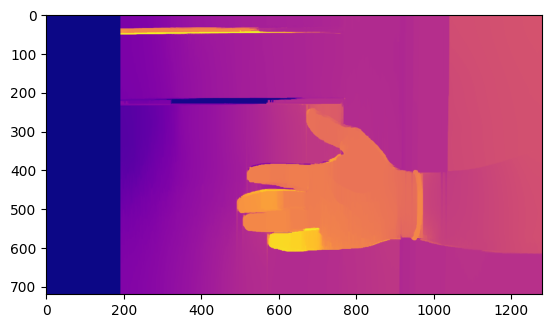

In [ ]:
filename = r'' \
'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/data-extraction/New-trimmed_stereo/amik-vid-6-S-hand-img_2026-07-06_211521/amik-vid-6-S-frame-6-2026-07-06_211521.jpg'

imgrayL, imgrayR, img_left_rectified, img_right_rectified, Q, P1 = rectify_validation(filename) 
displ, dispr, disparity_float, disparity_vis = main_stereo_wls(imgrayL, imgrayR, numDisparities=12, lmbda=60000, blockSize=3
                                                               )

plt.imshow(disparity_float, cmap='plasma')

In [ ]:
points, colors = disparity_to_pointcloud_debug(
    disparity_float = disparity_float,
    rect_left_color = cv2.cvtColor(img_left_rectified, cv2.COLOR_BGR2RGB),
    Q=Q,
    min_disparity=0.0,
    max_depth=5.0
)


=== Disparity Info ===
min: -1.0
max: 185.625
count > min_disparity: 783360
=== Z Before Depth Filter ===
Z min: 0.61769265
Z max: 96.555115
Z mean: 1.969181
count Z > 0: 783360
count Z < 0: 0
Final points: 779535


### Save Pointcloud & Visualize

In [ ]:
save_pointcloud_ply(
    "pointcloud_wls.ply",
    points,
    colors
)
print("dtype:", disparity_float.dtype)
print("shape:", disparity_float.shape)
print("min:", np.nanmin(disparity_float))
print("max:", np.nanmax(disparity_float))
print("mean:", np.nanmean(disparity_float))

print("count > 0   :", np.sum(disparity_float > 0))
print("count > 0.1 :", np.sum(disparity_float > 0.1))
print("count > 1.0 :", np.sum(disparity_float > 1.0))
print("count > 2.0 :", np.sum(disparity_float > 2.0))

print("points shape:", points.shape)
print("X min/max:", points[:, 0].min(), points[:, 0].max())
print("Y min/max:", points[:, 1].min(), points[:, 1].max())
print("Z min/max:", points[:, 2].min(), points[:, 2].max())

Saved pointcloud: pointcloud_wls.ply
Number of points: 779535
dtype: float32
shape: (720, 1280)
min: -1.0
max: 185.625
mean: 68.0656
count > 0   : 783360
count > 0.1 : 783360
count > 1.0 : 783360
count > 2.0 : 780171
points shape: (779535, 3)
X min/max: -1.1420525 0.6910112
Y min/max: -0.42980802 0.58244574
Z min/max: 0.61769265 4.866173


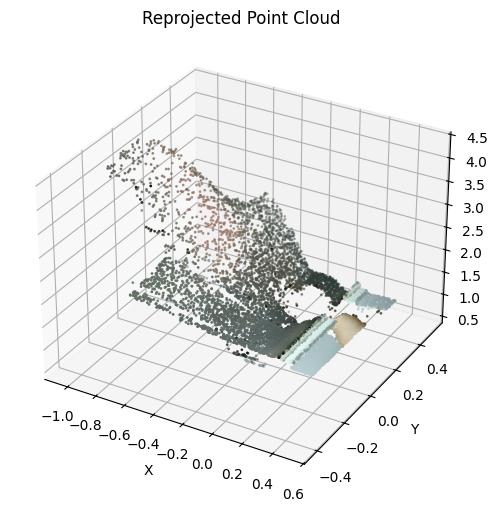

In [ ]:
visualize_pointcloud_matplotlib(
    points,
    colors,
    sample=10000
)

## Mediapipe Pipeline

### Generate & Visualize landmarks

In [ ]:
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode


def detect_hand_landmarks_tasks(
    img_left_rectified,
    model_path                          = r"models/hand_landmarker.task",
    num_hands                           = 1,
    min_hand_detection_confidence       = 0.5,
    min_hand_presence_confidence        = 0.5,
    min_tracking_confidence             = 0.5
):
    img_rgb = cv2.cvtColor(
        img_left_rectified,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=img_rgb
    )

    options = HandLandmarkerOptions(
        base_options=BaseOptions(
            model_asset_path=model_path
        ),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=num_hands,
        min_hand_detection_confidence=min_hand_detection_confidence,
        min_hand_presence_confidence=min_hand_presence_confidence,
        min_tracking_confidence=min_tracking_confidence
    )

    with HandLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    return result

In [ ]:
def hand_landmarker_result_to_pixels(result, image_shape):
    h, w = image_shape[:2]

    if result.hand_landmarks is None or len(result.hand_landmarks) == 0:
        return None

    hand_landmarks = result.hand_landmarks[0]

    landmarks_2d = []

    for lm in hand_landmarks:
        u = int(lm.x * w)
        v = int(lm.y * h)

        landmarks_2d.append([u, v])

    return np.array(landmarks_2d, dtype=np.int32)

In [ ]:
result = detect_hand_landmarks_tasks(
    img_left_rectified=img_left_rectified,
    model_path=r"./hand_landmarker.task"
)

landmarks_2d = hand_landmarker_result_to_pixels(
    result,
    img_left_rectified.shape
)

I0000 00:00:1783495089.187902    5780 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1783495089.191997    5804 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: RENOIR (renoir, LLVM 15.0.7, DRM 3.57, 6.8.0-124-generic)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1783495089.219583    5782 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783495089.240724    5788 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783495089.269320    5790 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [ ]:
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),          # thumb
    (5, 6), (6, 7), (7, 8),                  # index
    (9, 10), (10, 11), (11, 12),             # middle
    (13, 14), (14, 15), (15, 16),            # ring
    (0, 17), (17, 18), (18, 19), (19, 20),   # pinky
    (1, 5), (5, 9), (9, 13), (13, 17)        # palm
]


def draw_hand_landmarks_manual(
    image,
    landmarks_2d,
    draw_id=True,
    point_radius=5,
    line_thickness=2
):
    """
    Menggambar 21 hand landmarks pada gambar kiri rectified.

    image:
        BGR image dari OpenCV.

    landmarks_2d:
        np.ndarray shape (21, 2), berisi [u, v].
    """

    img_draw = image.copy()

    if landmarks_2d is None:
        print("Tidak ada landmark untuk digambar.")
        return img_draw

    h, w = img_draw.shape[:2]

    # Gambar koneksi antar landmark
    for start_idx, end_idx in HAND_CONNECTIONS:
        u1, v1 = landmarks_2d[start_idx]
        u2, v2 = landmarks_2d[end_idx]

        if (
            0 <= u1 < w and 0 <= v1 < h and
            0 <= u2 < w and 0 <= v2 < h
        ):
            cv2.line(
                img_draw,
                (int(u1), int(v1)),
                (int(u2), int(v2)),
                (0, 255, 0),
                line_thickness
            )

    # Gambar titik landmark
    for idx, (u, v) in enumerate(landmarks_2d):
        if 0 <= u < w and 0 <= v < h:
            cv2.circle(
                img_draw,
                (int(u), int(v)),
                point_radius,
                (0, 0, 255),
                -1
            )

            if draw_id:
                cv2.putText(
                    img_draw,
                    str(idx),
                    (int(u) + 5, int(v) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (255, 0, 0),
                    1,
                    cv2.LINE_AA
                )

    return img_draw, image

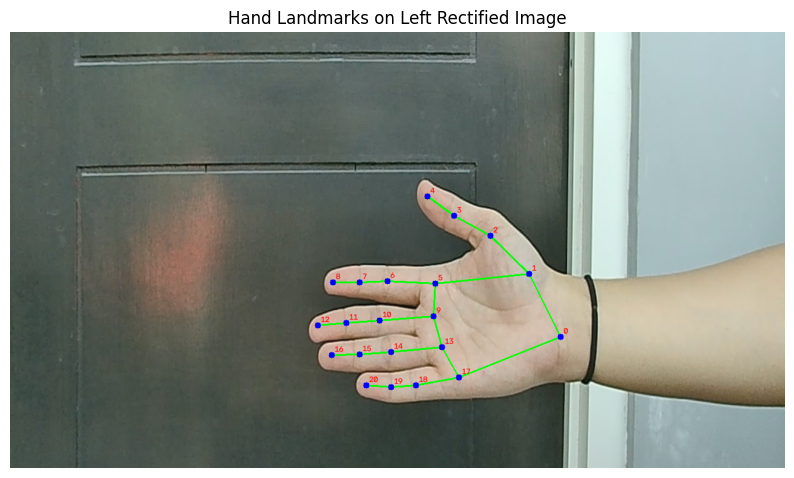

In [ ]:
img_landmark, img_left_rectified = draw_hand_landmarks_manual(
    image=img_left_rectified,
    landmarks_2d=landmarks_2d,
    draw_id=True
)

plt.figure(figsize=(10, 6))
plt.title("Hand Landmarks on Left Rectified Image")
plt.axis("off")
plt.imshow(img_landmark)

### Generate 3D landmarks from disparity

In [ ]:
def get_3d_landmarks_from_disparity(
    landmarks_2d,
    disparity_float,
    Q,
    window_size=5,
    min_disparity=0.1
):
    """
    Mengubah landmark 2D menjadi landmark 3D menggunakan disparity map dan Q.

    landmarks_2d:
        np.ndarray shape (21, 2), berisi [u, v]

    disparity_float:
        disparity asli dalam pixel, bukan hasil normalisasi visualisasi.

    Q:
        reprojection matrix dari stereoRectify.

    Output:
        landmarks_3d: np.ndarray shape (21, 3)
                      berisi [X, Y, Z] dalam satuan kalibrasi.
                      Jika SQUARE_SIZE = 0.03 meter, maka X,Y,Z dalam meter.
    """

    h, w = disparity_float.shape[:2]

    points_3d_map = cv2.reprojectImageTo3D(
        disparity_float.astype(np.float32),
        Q
    )

    half = window_size // 2

    landmarks_3d = []

    for u, v in landmarks_2d:
        if u < 0 or u >= w or v < 0 or v >= h:
            landmarks_3d.append([np.nan, np.nan, np.nan])
            continue

        x1 = max(u - half, 0)
        x2 = min(u + half + 1, w)

        y1 = max(v - half, 0)
        y2 = min(v + half + 1, h)

        disparity_patch = disparity_float[y1:y2, x1:x2]
        points_patch = points_3d_map[y1:y2, x1:x2]

        valid_mask = disparity_patch > min_disparity
        valid_mask = valid_mask & np.isfinite(disparity_patch)
        valid_mask = valid_mask & np.isfinite(points_patch).all(axis=-1)

        if np.sum(valid_mask) == 0:
            landmarks_3d.append([np.nan, np.nan, np.nan])
            continue

        valid_points = points_patch[valid_mask]

        # Median lebih robust dibanding mengambil 1 pixel saja
        point_3d = np.median(
            valid_points,
            axis=0
        )

        landmarks_3d.append(point_3d)

    landmarks_3d = np.array(
        landmarks_3d,
        dtype=np.float32
    )

    return landmarks_3d

In [ ]:
landmarks_3d = get_3d_landmarks_from_disparity(landmarks_2d, disparity_float, Q, min_disparity= 0.1)

## Generate Sumbu Normal Z lokal tangan

### Normal Z local axis generator

In [ ]:
def normalize_vector(v, eps=1e-8):
    norm = np.linalg.norm(v)

    if norm < eps:
        return None

    return v / norm


def compute_palm_normal_from_landmarks(
    landmarks_3d,
    palm_indices=[0, 5, 9, 13, 17],
    normal_facing_camera=True
):
    """
    Menghitung normal telapak tangan dari landmark 3D.

    landmarks_3d:
        np.ndarray shape (21, 3), berisi [X, Y, Z] dalam koordinat kamera OpenCV.

    Output:
        palm_center: titik tengah telapak
        palm_normal: vektor normal telapak, shape (3,)
    """

    palm_points = landmarks_3d[palm_indices]

    # Buang landmark yang NaN
    valid = np.isfinite(palm_points).all(axis=1)
    palm_points = palm_points[valid]

    if len(palm_points) < 3:
        raise ValueError("Titik palm valid kurang dari 3. Tidak bisa hitung normal.")

    palm_center = np.mean(palm_points, axis=0)

    centered = palm_points - palm_center

    # PCA / SVD untuk mencari normal bidang
    _, _, vh = np.linalg.svd(centered)

    # Normal bidang adalah eigenvector dengan variance terkecil
    palm_normal = vh[-1]

    palm_normal = normalize_vector(palm_normal)

    if palm_normal is None:
        raise ValueError("Normal gagal dihitung.")

    # Orientasikan normal agar menghadap kamera
    # Kamera berada di origin [0, 0, 0]
    if normal_facing_camera:
        direction_to_camera = -palm_center

        if np.dot(palm_normal, direction_to_camera) < 0:
            palm_normal = -palm_normal

    return palm_center, palm_normal

In [ ]:
palm_center, palm_normal = compute_palm_normal_from_landmarks(
    landmarks_3d,
    palm_indices=[0, 5, 9, 13, 17],
    normal_facing_camera=True
)

print("Palm center:", palm_center)
print("Palm normal:", palm_normal)

Palm center: [0.05055211 0.08847626 0.91951764]
Palm normal: [ 0.58329654 -0.43128338 -0.6883021 ]


### T and R matrix generator from pointcloud and 3D landmarks

In [ ]:
def compute_hand_coordinate_frame(landmarks_3d):
    """
    Membuat frame koordinat lokal tangan dari landmark 3D.

    Output:
        R_cam_hand:
            Matriks rotasi 3x3.
            Kolom ke-0 = X_hand dalam koordinat kamera
            Kolom ke-1 = Y_hand dalam koordinat kamera
            Kolom ke-2 = Z_hand dalam koordinat kamera

        t_cam_hand:
            Translation / center tangan dalam koordinat kamera
    """

    palm_center, z_axis = compute_palm_normal_from_landmarks(
        landmarks_3d,
        palm_indices=[0, 5, 9, 13, 17],
        normal_facing_camera=True
    )

    wrist = landmarks_3d[0]
    middle_mcp = landmarks_3d[9]

    if not np.isfinite(wrist).all() or not np.isfinite(middle_mcp).all():
        raise ValueError("Landmark wrist atau middle_mcp tidak valid.")

    # Arah dari wrist ke tengah telapak / jari
    y_axis = middle_mcp - wrist

    # Hilangkan komponen y yang sejajar dengan z
    y_axis = y_axis - np.dot(y_axis, z_axis) * z_axis
    y_axis = normalize_vector(y_axis)

    if y_axis is None:
        raise ValueError("Gagal membuat Y axis.")

    # Buat sistem koordinat tangan yang orthogonal
    x_axis = np.cross(y_axis, z_axis)
    x_axis = normalize_vector(x_axis)

    if x_axis is None:
        raise ValueError("Gagal membuat X axis.")

    # Recompute Y supaya benar-benar orthogonal
    y_axis = np.cross(z_axis, x_axis)
    y_axis = normalize_vector(y_axis)

    R_cam_hand = np.stack(
        [
            x_axis,
            y_axis,
            z_axis
        ],
        axis=1
    )

    t_cam_hand = palm_center

    return R_cam_hand, t_cam_hand

In [ ]:
R_cam_hand, t_cam_hand = compute_hand_coordinate_frame(
    landmarks_3d
)

print("R_cam_hand:")
print(R_cam_hand)

print("t_cam_hand:")
print(t_cam_hand)

R_cam_hand:
[[-0.11020514 -0.8047484   0.58329654]
 [-0.88157713 -0.19187586 -0.43128338]
 [ 0.4589951  -0.5617506  -0.6883021 ]]
t_cam_hand:
[0.05055211 0.08847626 0.91951764]


## Visualize the final T and R 

### Reproject Function from 3D to 2D for 2D visualization

In [ ]:
HAND_CONNECTIONS = [
    (0, 1), (1, 5), (5, 9), 
    (9, 13), (13, 17), (0, 17), 
    (0, 5)
]


def project_3d_to_2d(points_3d, K):
    """
    Project 3D point camera coordinate ke pixel image.
    points_3d: shape (N, 3)
    K: camera matrix 3x3
    """

    points_3d = np.asarray(points_3d, dtype=np.float32)

    X = points_3d[:, 0]
    Y = points_3d[:, 1]
    Z = points_3d[:, 2]

    u = K[0, 0] * X / Z + K[0, 2]
    v = K[1, 1] * Y / Z + K[1, 2]

    points_2d = np.stack([u, v], axis=1)

    return points_2d


def draw_pseudo_pose_2d(
    image,
    landmarks_2d,
    R_cam_hand,
    t_cam_hand,
    K_rect,
    axis_length=0.05,
    draw_id=True
):
    """
    Visualisasi landmark 2D dan sumbu pose tangan di gambar kiri rectified.

    R_cam_hand:
        kolom 0 = X hand
        kolom 1 = Y hand
        kolom 2 = Z hand / normal palm

    t_cam_hand:
        pusat palm dalam koordinat kamera
    """

    img_draw = image.copy()
    h, w = img_draw.shape[:2]

    # Gambar koneksi tangan
    for i, j in HAND_CONNECTIONS:
        u1, v1 = landmarks_2d[i]
        u2, v2 = landmarks_2d[j]

        if (
            0 <= u1 < w and 0 <= v1 < h and
            0 <= u2 < w and 0 <= v2 < h
        ):
            cv2.line(
                img_draw,
                (int(u1), int(v1)),
                (int(u2), int(v2)),
                (50, 50, 0),
                2
            )

    # Gambar titik landmark
    for idx, (u, v) in enumerate(landmarks_2d):
        if 0 <= u < w and 0 <= v < h:
            cv2.circle(
                img_draw,
                (int(u), int(v)),
                5,
                (0, 30, 30),
                -1
            )

            if draw_id:
                cv2.putText(
                    img_draw,
                    str(idx),
                    (int(u) + 5, int(v) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (255, 0, 0),
                    1,
                    cv2.LINE_AA
                )

    # Buat endpoint sumbu lokal tangan
    center = t_cam_hand.reshape(3)

    x_end = center + axis_length * R_cam_hand[:, 0]
    y_end = center + axis_length * R_cam_hand[:, 1]
    z_end = center + axis_length * R_cam_hand[:, 2]

    axis_points_3d = np.stack(
        [center, x_end, y_end, z_end],
        axis=0
    )

    axis_points_2d = project_3d_to_2d(
        axis_points_3d,
        K_rect
    )

    c = axis_points_2d[0].astype(int)
    x = axis_points_2d[1].astype(int)
    y = axis_points_2d[2].astype(int)
    z = axis_points_2d[3].astype(int)

    c_tuple = (int(c[0]), int(c[1]))

    # X merah
    cv2.arrowedLine(
        img_draw,
        c_tuple,
        (int(x[0]), int(x[1])),
        (255, 0, 0),
        4,
        tipLength=0.25
    )

    # Y hijau
    cv2.arrowedLine(
        img_draw,
        c_tuple,
        (int(y[0]), int(y[1])),
        (0, 255, 0),
        4,
        tipLength=0.25
    )

    # Z biru = normal telapak
    cv2.arrowedLine(
        img_draw,
        c_tuple,
        (int(z[0]), int(z[1])),
        (0, 0, 255),
        4,
        tipLength=0.25
    )

    cv2.putText(img_draw, "X", (int(x[0]), int(x[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    cv2.putText(img_draw, "Y", (int(y[0]), int(y[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.putText(img_draw, "Z", (int(z[0]), int(z[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    return img_draw

### Call it! Here's the moment of truth

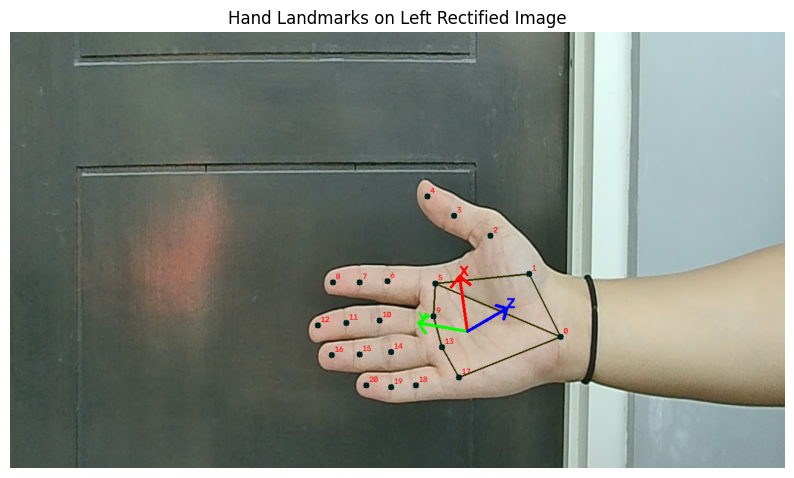

In [ ]:
K_rect = P1[:3, :3]

img_pose_2d = draw_pseudo_pose_2d(
    image=img_left_rectified,
    landmarks_2d=landmarks_2d,
    R_cam_hand=R_cam_hand,
    t_cam_hand=t_cam_hand,
    K_rect=K_rect,
    axis_length=0.05
)

plt.figure(figsize=(10, 6))
plt.title("Hand Landmarks on Left Rectified Image")
plt.axis("off")
plt.imshow(img_pose_2d)


### 3D visualization with pointcloud and landmark

In [ ]:
import open3d as o3d

def create_landmark_lineset(landmarks_3d):
    """
    Membuat skeleton tangan 3D dari landmarks.
    """

    points = []
    index_map = {}

    for i, p in enumerate(landmarks_3d):
        if np.isfinite(p).all():
            index_map[i] = len(points)
            points.append(p)

    lines = []

    for i, j in HAND_CONNECTIONS:
        if i in index_map and j in index_map:
            lines.append([index_map[i], index_map[j]])

    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(np.asarray(points))
    line_set.lines = o3d.utility.Vector2iVector(np.asarray(lines))

    # Hijau untuk skeleton
    line_set.colors = o3d.utility.Vector3dVector(
        np.tile(np.array([[0.0, 1.0, 0.0]]), (len(lines), 1))
    )

    return line_set


def create_landmark_pointcloud(landmarks_3d):
    """
    Membuat pointcloud khusus untuk 21 landmark.
    """

    valid = np.isfinite(landmarks_3d).all(axis=1)
    landmark_points = landmarks_3d[valid]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(landmark_points)

    # Merah untuk titik landmark
    colors = np.tile(
        np.array([[1.0, 0.0, 0.0]]),
        (len(landmark_points), 1)
    )

    pcd.colors = o3d.utility.Vector3dVector(colors)

    return pcd


def create_hand_axis_lineset(
    R_cam_hand,
    t_cam_hand,
    axis_length=0.07
):
    """
    Membuat sumbu lokal tangan:
    X = merah
    Y = hijau
    Z = biru / normal palm
    """

    center = t_cam_hand.reshape(3)

    x_end = center + axis_length * R_cam_hand[:, 0]
    y_end = center + axis_length * R_cam_hand[:, 1]
    z_end = center + axis_length * R_cam_hand[:, 2]

    points_axis = np.stack(
        [
            center,
            x_end,
            y_end,
            z_end
        ],
        axis=0
    )

    lines_axis = np.array(
        [
            [0, 1],
            [0, 2],
            [0, 3]
        ],
        dtype=np.int32
    )

    colors_axis = np.array(
        [
            [1.0, 0.0, 0.0],   # X merah
            [0.0, 1.0, 0.0],   # Y hijau
            [0.0, 0.0, 1.0]    # Z biru
        ],
        dtype=np.float64
    )

    axis_line_set = o3d.geometry.LineSet()
    axis_line_set.points = o3d.utility.Vector3dVector(points_axis)
    axis_line_set.lines = o3d.utility.Vector2iVector(lines_axis)
    axis_line_set.colors = o3d.utility.Vector3dVector(colors_axis)

    return axis_line_set


def crop_pointcloud_around_landmarks(
    points,
    colors,
    landmarks_3d,
    margin=0.20
):
    """
    Crop pointcloud di sekitar tangan supaya validasi lebih jelas.
    margin dalam meter jika SQUARE_SIZE = 0.03 meter.
    """

    valid_landmarks = landmarks_3d[np.isfinite(landmarks_3d).all(axis=1)]

    if len(valid_landmarks) == 0:
        return points, colors

    min_bound = valid_landmarks.min(axis=0) - margin
    max_bound = valid_landmarks.max(axis=0) + margin

    mask = np.all(
        (points >= min_bound) & (points <= max_bound),
        axis=1
    )

    return points[mask], colors[mask]


def visualize_pseudo_dataset_3d(
    points,
    colors,
    landmarks_3d,
    R_cam_hand,
    t_cam_hand,
    crop=True,
    crop_margin=0.20,
    voxel_size=0.003,
    axis_length=0.07
):
    """
    Visualisasi 3D:
    - pointcloud tangan
    - landmark 3D
    - skeleton tangan
    - sumbu lokal X/Y/Z tangan
    """

    points_vis = points.copy()
    colors_vis = colors.copy()

    if crop:
        points_vis, colors_vis = crop_pointcloud_around_landmarks(
            points_vis,
            colors_vis,
            landmarks_3d,
            margin=crop_margin
        )

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_vis)

    if colors_vis.max() > 1.0:
        colors_norm = colors_vis.astype(np.float64) / 255.0
    else:
        colors_norm = colors_vis.astype(np.float64)

    pcd.colors = o3d.utility.Vector3dVector(colors_norm)

    if voxel_size is not None and voxel_size > 0:
        pcd = pcd.voxel_down_sample(voxel_size=voxel_size)

    landmark_pcd = create_landmark_pointcloud(landmarks_3d)
    landmark_skeleton = create_landmark_lineset(landmarks_3d)

    hand_axis = create_hand_axis_lineset(
        R_cam_hand=R_cam_hand,
        t_cam_hand=t_cam_hand,
        axis_length=axis_length
    )

    camera_axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.10,
        origin=[0, 0, 0]
    )

    o3d.visualization.draw_geometries(
        [
            pcd,
            landmark_pcd,
            landmark_skeleton,
            hand_axis,
            camera_axis
        ],
        window_name="Pseudo Dataset 3D Validation",
        width=1280,
        height=720
    )

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### The final moments!!!

In [ ]:
visualize_pseudo_dataset_3d(
    points=points,
    colors=colors,
    landmarks_3d=landmarks_3d,
    R_cam_hand=R_cam_hand,
    t_cam_hand=t_cam_hand,
    crop=True,
    crop_margin=0.20,
    voxel_size=0.003,
    axis_length=0.07
)

: 

## Last: renew calibration.npz by adding P1, P2 and Q data

In [3]:
def add_rectification_to_calibration(
    calib_path,
    output_path,
    image_size=(1280, 720),  # OpenCV format: (width, height)
    alpha=0
):
    with np.load(calib_path) as data:
        K_left = data["K_left"]
        D_left = data["D_left"]
        K_right = data["K_right"]
        D_right = data["D_right"]
        R = data["R"]
        T = data["T"]

    R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
        cameraMatrix1=K_left,
        distCoeffs1=D_left,
        cameraMatrix2=K_right,
        distCoeffs2=D_right,
        imageSize=image_size,
        R=R,
        T=T,
        alpha=alpha
    )

    np.savez(
        output_path,
        K_left=K_left,
        D_left=D_left,
        K_right=K_right,
        D_right=D_right,
        R=R,
        T=T,
        R1=R1,
        R2=R2,
        P1=P1,
        P2=P2,
        Q=Q,
        roi1=roi1,
        roi2=roi2
    )

    print("Saved updated calibration:", output_path)
    print("P1:")
    print(P1)
    print("P2:")
    print(P2)
    print("Q:")
    print(Q)

In [5]:
add_rectification_to_calibration(
    calib_path="./Kalibrasi/New-Kalibrasi-07072026.npz",
    output_path="./Kalibrasi/New-Kalibrasi-07072026.npz",
    image_size=(1280, 720),
    alpha=0
)

Saved updated calibration: ./Kalibrasi/New-Kalibrasi-07072026.npz
P1:
[[1.85818763e+03 0.00000000e+00 6.53237438e+02 0.00000000e+00]
 [0.00000000e+00 1.85818763e+03 3.16061634e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]
P2:
[[ 1.85818763e+03  0.00000000e+00  6.53237438e+02 -1.14659201e+02]
 [ 0.00000000e+00  1.85818763e+03  3.16061634e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]
Q:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -6.53237438e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -3.16061634e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.85818763e+03]
 [ 0.00000000e+00  0.00000000e+00  1.62061798e+01 -0.00000000e+00]]
